![banner](../../../docs/figs/brand_identity/banner.png)

# Week 9: Interpreting Housing Predictions

## Lesson overview

Train a housing-price model, then use SHAP to inspect which inputs are most associated with changes in its predictions. Also examine a regional subset and an individual example.

**By the end, you can:** distinguish overall explanations from individual examples; read positive and negative effects in SHAP plots; and explain why model explanations and associations are not causal claims.

**Before you begin:** The housing CSV is included in the repository; no data download is needed. SHAP calculations may take time. Plots describe how this model uses the data, not real-world causal mechanisms.

<p align="center"><img src="../figs/shap_learning_map.svg" alt="Housing rows train a predictor; global and local attribution views answer different model-explanation questions" width="100%"><br><em>Figure 1. Fit the predictor before asking how it uses features across rows and for one example.</em></p>


## Why this example matters

A housing predictor can fit test data while remaining difficult to interpret. SHAP helps describe how this fitted model attributes individual predictions to features, and the regional comparison asks whether those descriptions vary across subsets.

**Inputs and requirements:** Included California housing CSV, PyTorch, SHAP, pandas, and plotting libraries. Attribution is relative to a reference prediction and is not a causal effect.

**Route through the lesson:** Prepare and fit a predictor → view global attributions → compare selected regions → inspect one local attribution → state the limits of the explanation.

**As you work:** Before each model or plot cell, predict one result. After it runs, describe one observation, identify its source, and name one limitation.


## Why interpret a housing model?

A predictive model can be accurate on a test set while its reasoning remains hard to inspect. Feature importance and SHAP values help describe which inputs influenced model predictions. Here the model predicts California housing values from variables such as median income, location, and house age.

The workflow is **load labelled housing data → train the predictor → calculate global and local explanations → inspect maps/plots**. An explanation describes this fitted model and dataset; it does not prove a feature causes house prices to change.


In [7]:
import shap
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader, TensorDataset, random_split
import pandas as pd
from ccai9012.paths import DATA_DIR
from sklearn.preprocessing import StandardScaler
import numpy as np
import matplotlib.pyplot as plt

In [9]:
from ccai9012 import nn_utils, viz_utils

## Step 1: Load local dataset and prepare for model training (same process as week 2)

Load the housing features and target values and prepare training examples. Check that each row’s features and target refer to the same area.

In [11]:
# Read the local California housing table.
california = pd.read_csv(DATA_DIR / "housing_price_california.csv", index_col=0)
feature_names = list(california.drop(columns="Target").columns)
X_california = california[feature_names].to_numpy()
y_california = california["Target"].to_numpy()

# Normarlize data and prepare dataloaders
train_loader, val_loader, test_loader, scaler = nn_utils.prepare_dataloaders(
    X_california,
    y_california,
    batch_size=64,
    train_ratio=0.8,
    val_ratio=0.1
)

## Step 2: Define and train the model (a simple MLP)

Train the prediction model and inspect the validation results. The explanations that follow apply only to this fitted model.

In [13]:
# Model Build: Two-layer MLP
class SimpleMLP(nn.Module):
    def __init__(self, input_dim, hidden_dim):
        super(SimpleMLP, self).__init__()
        self.fc1 = nn.Linear(input_dim, hidden_dim)
        self.relu = nn.ReLU()
        self.fc2 = nn.Linear(hidden_dim, 1)  # regression output

    def forward(self, x):
        x = self.fc1(x)
        x = self.relu(x)
        x = self.fc2(x)
        return x


input_dim = X_california.shape[1]  # 8 features
hidden_dim = 64  # can tune this

# Initialize the model
device = nn_utils.get_best_device()
model = SimpleMLP(input_dim, hidden_dim).to(device)

In [15]:
# Training Setup
learning_rate = 0.001  # step size for optimizer
num_epochs = 50        # number of passes over entire dataset
criterion = nn.MSELoss()  # Mean Squared Error loss for regression
optimizer = optim.Adam(model.parameters(), lr=learning_rate)

train_losses, val_losses = nn_utils.train_model(
    model,
    train_loader,
    val_loader,
    optimizer,
    criterion,
    num_epochs
)

Epoch [1/50] - Train Loss: 1.3904, Val Loss: 0.7479
Epoch [2/50] - Train Loss: 0.5919, Val Loss: 0.5697
Epoch [3/50] - Train Loss: 0.4660, Val Loss: 0.5056
Epoch [4/50] - Train Loss: 0.4269, Val Loss: 0.4796
Epoch [5/50] - Train Loss: 0.4101, Val Loss: 0.4583
Epoch [6/50] - Train Loss: 0.3982, Val Loss: 0.4499
Epoch [7/50] - Train Loss: 0.3899, Val Loss: 0.4376
Epoch [8/50] - Train Loss: 0.3827, Val Loss: 0.4314
Epoch [9/50] - Train Loss: 0.3780, Val Loss: 0.4227
Epoch [10/50] - Train Loss: 0.3731, Val Loss: 0.4180
Epoch [11/50] - Train Loss: 0.3687, Val Loss: 0.4141
Epoch [12/50] - Train Loss: 0.3641, Val Loss: 0.4056
Epoch [13/50] - Train Loss: 0.3594, Val Loss: 0.4021
Epoch [14/50] - Train Loss: 0.3568, Val Loss: 0.3993
Epoch [15/50] - Train Loss: 0.3506, Val Loss: 0.3949
Epoch [16/50] - Train Loss: 0.3514, Val Loss: 0.3889
Epoch [17/50] - Train Loss: 0.3460, Val Loss: 0.3868
Epoch [18/50] - Train Loss: 0.3474, Val Loss: 0.3832
Epoch [19/50] - Train Loss: 0.3422, Val Loss: 0.3789
Ep

## Step 3: Global explanation with SHAP

Start with the SHAP plot for all examples: positive values push a prediction higher and negative values push it lower. The size of the effect depends on the model and example.

**Before running:** Predict which features the fitted model might use most. **After running:** Read each point as an attribution for one model prediction. The horizontal SHAP value is a change from a reference prediction, not the real-world effect of changing that feature.


<p align="center"><img src="../figs/shap_california_waterfall_official.png" alt="SHAP waterfall plot for a California housing prediction: red features increase the prediction, blue features decrease it, moving from E[f(X)] = 1.992 to f(x) = 3.495" width="85%"><br><em>Official SHAP California housing example (XGBoost model); this is a reading example, not an output of the model trained below. Source: <a href="https://shap.readthedocs.io/en/latest/example_notebooks/tabular_examples/model_agnostic/Simple%20California%20Demo.html#plots-to-explain-the-instance">SHAP documentation, Simple California Demo 2.0</a>.</em></p>

**How to read this example:** Start at the reference prediction $E[f(X)] = 1.992$ at the bottom. Red contributions raise this prediction and blue contributions lower it; together they reach $f(x) = 3.495$ for this one house. The grey number before each feature name is that house's feature value (for example, `8.301 = MedInc`), while the number on a coloured bar is its SHAP contribution (here `+1.08` for `MedInc`). These are model attributions relative to a reference, not causal effects of changing housing features.

**Read the upcoming plots:** The next summary plot combines local attributions from many houses. Each point represents one prediction, so a feature's overall pattern need not hold for every house.


In [17]:
# train_loader.dataset is a Subset object; .dataset points to the original TensorDataset
full_dataset = train_loader.dataset.dataset

# tensors[0] contains features, tensors[1] contains labels
X_tensor = full_dataset.tensors[0].to(device)
y_tensor = full_dataset.tensors[1].to(device)

print("X_tensor shape:", X_tensor.shape)
print("y_tensor shape:", y_tensor.shape)

X_tensor shape: torch.Size([20640, 8])
y_tensor shape: torch.Size([20640, 1])


In [19]:
# Define SHAP explainer with background data
background = X_tensor[:100]  # background for SHAP, the average prediction of the samples as baseline

# Initialize SHAP DeepExplainer
# SHAP compares this model output with a reference set of examples.
explainer = shap.DeepExplainer(model, background)

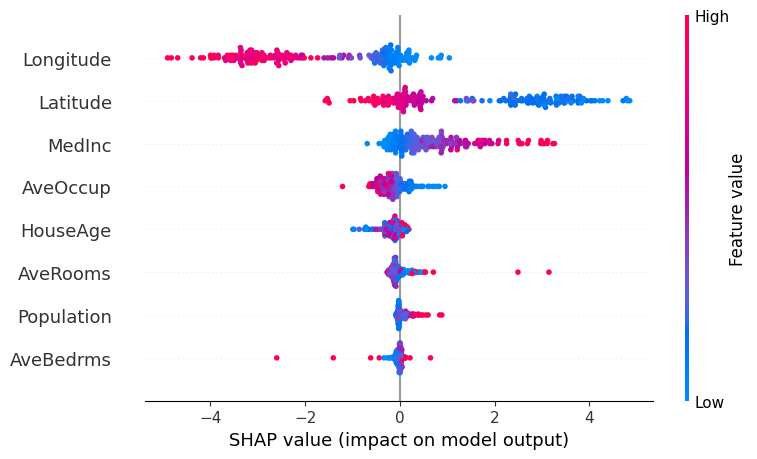

In [21]:
# Randomly sample 200 examples from X_tensor
n_global = 200
idx = np.random.choice(X_tensor.shape[0], n_global, replace=False)
X_global = X_tensor[idx]

# Compute SHAP values
shap_values_global = explainer.shap_values(X_global).squeeze(-1)

# Convert back to numpy for SHAP plots
X_global_np = X_global.cpu().numpy()

# SHAP summary plot (global explanation)
shap.summary_plot(shap_values_global, X_global_np, feature_names=feature_names)

### Read the location result cautiously

Inspect the latitude and longitude attributions in the plot above. If they are large for this fitted model, they show that location features help explain **its predictions on these rows**. Next compare the map of recorded targets: does the spatial pattern offer context for why the model might use location? This comparison does not establish a causal effect of geography.


In [23]:
import pandas as pd

# Prepare data in DataFrame
df = pd.DataFrame({
    'latitude': X_california[:, feature_names.index('Latitude')],
    'longitude': X_california[:, feature_names.index('Longitude')],
    'price': y_california.flatten()
})

m = viz_utils.plot_heatmap(df, target_col='price')
m

/Users/kanxuanhe/Document/250421_AI_course/ccai9012/ccai9012/viz_utils.py:395: UserWarning: The `max_val` parameter is no longer necessary. The largest intensity is calculated automatically.
  HeatMap(


The map displays target values for the selected sample. Locate Los Angeles and another region, then describe a visible difference without assuming every neighbourhood follows it. The next section asks whether the fitted model attributes predictions differently inside the selected regional subset.


## Step 4: Global explanation within sub-dataset of selected cities

Now look only at the selected city areas and compare which features matter within them. Results are less stable when there are few examples.

In [25]:
# Define approximate latitude and longitude ranges for selected CA cities
city_bounds = {
    'Los Angeles':   {'lat_min': 33.7, 'lat_max': 34.4, 'lon_min': -118.7, 'lon_max': -118.0},
    'San Francisco': {'lat_min': 37.6, 'lat_max': 37.9, 'lon_min': -123.0, 'lon_max': -122.3},
    'Sacramento':    {'lat_min': 38.4, 'lat_max': 38.7, 'lon_min': -121.7, 'lon_max': -121.3},
    'Fresno':        {'lat_min': 36.7, 'lat_max': 36.9, 'lon_min': -120.0, 'lon_max': -119.6},
    'Bakersfield':   {'lat_min': 35.3, 'lat_max': 35.5, 'lon_min': -119.1, 'lon_max': -118.8},
}

# Extract latitude and longitude columns by feature names
lat_idx = feature_names.index('Latitude')
lon_idx = feature_names.index('Longitude')

latitudes = X_california[:, lat_idx]
longitudes = X_california[:, lon_idx]

# Function to get indices of samples within the given city's lat/lon bounds
def filter_city_indices(city_name):
    bounds = city_bounds[city_name]
    idx = np.where(
        (latitudes >= bounds['lat_min']) & (latitudes <= bounds['lat_max']) &
        (longitudes >= bounds['lon_min']) & (longitudes <= bounds['lon_max'])
    )[0]
    return idx

# Example: get indices for Los Angeles samples
for city in city_bounds:
    indices = filter_city_indices(city)
    print(f"Number of samples in {city}: {len(indices)}")

Number of samples in Los Angeles: 5410
Number of samples in San Francisco: 763
Number of samples in Sacramento: 568
Number of samples in Fresno: 350
Number of samples in Bakersfield: 206


SHAP summary plot for Los Angeles (100 samples)


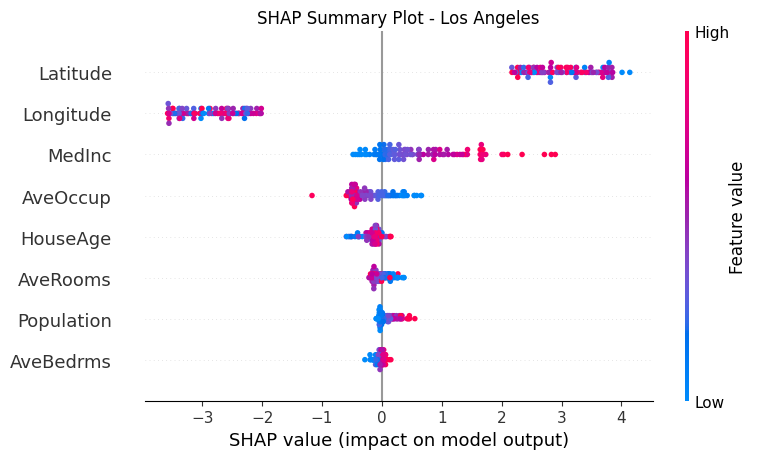

SHAP summary plot for San Francisco (100 samples)


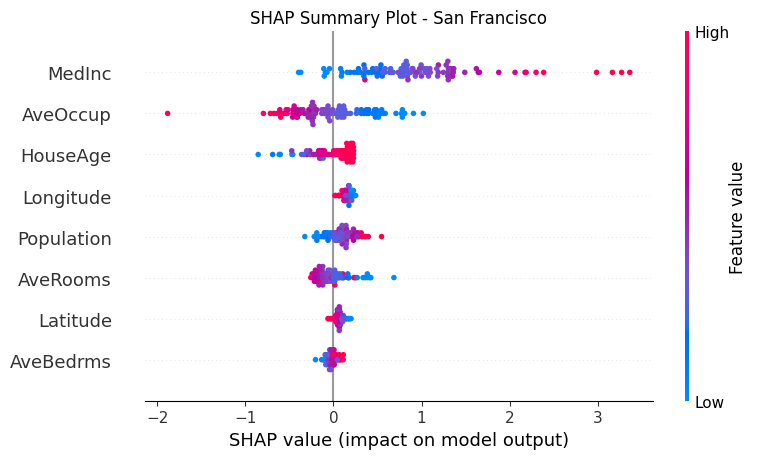

SHAP summary plot for Sacramento (100 samples)


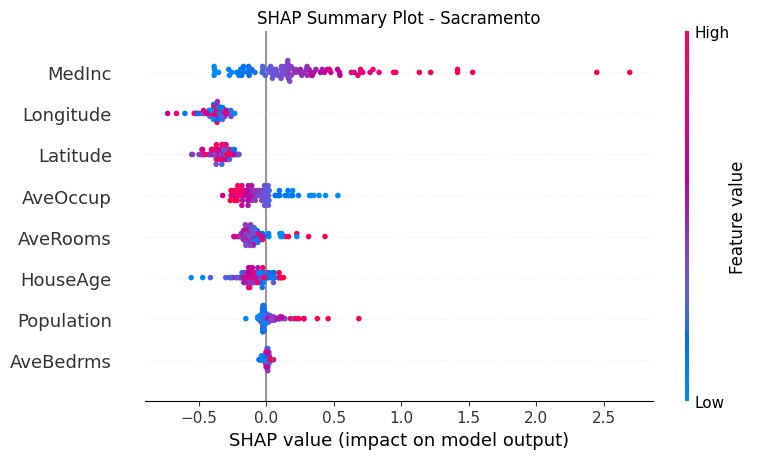

SHAP summary plot for Fresno (100 samples)


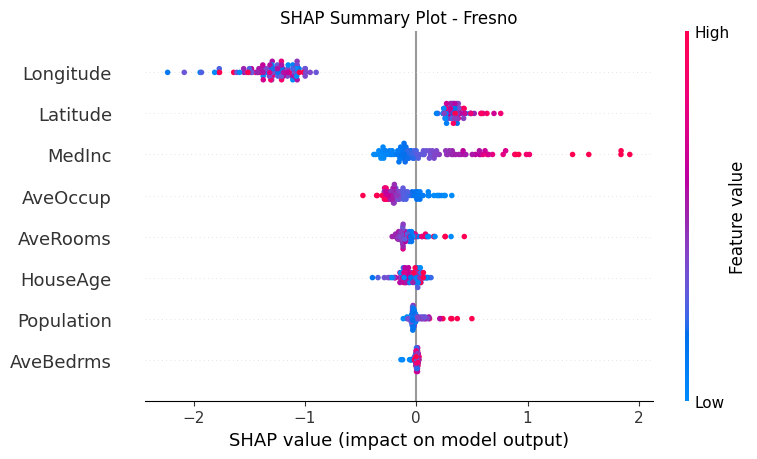

SHAP summary plot for Bakersfield (100 samples)


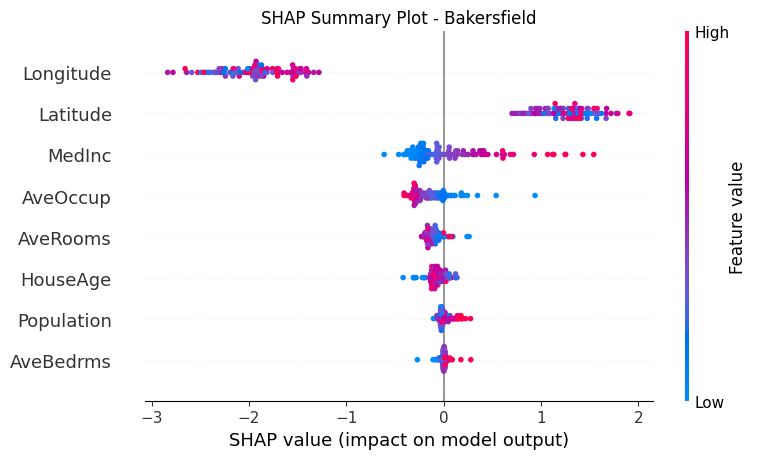

In [27]:
# Number of samples to randomly select from each city for SHAP analysis
n_samples_per_city = 100

city_samples = {}
for city in city_bounds:
    indices = filter_city_indices(city)
    if len(indices) == 0:
        print(f"No data for {city}, skipping...")
        continue
    # Randomly sample (without replacement) up to n_samples_per_city from this city
    sample_size = min(len(indices), n_samples_per_city)
    sampled_idx = np.random.choice(indices, sample_size, replace=False)
    city_samples[city] = sampled_idx

# Now compute SHAP values for each city's samples
shap_values_city = {}
for city, sample_indices in city_samples.items():
    X_city_sample = X_tensor[sample_indices]
    # Use the same explainer, background, and model as before
    shap_values = explainer.shap_values(X_city_sample).squeeze(-1)  # shape (sample_size, n_features)
    shap_values_city[city] = (shap_values, X_city_sample.cpu().numpy())

# Plot SHAP summary plots for all cities with available SHAP values
for city, (shap_vals, X_samples_np) in shap_values_city.items():
    print(f"SHAP summary plot for {city} ({shap_vals.shape[0]} samples)")
    plt.title(f"SHAP Summary Plot - {city}")
    shap.summary_plot(
        shap_vals,
        X_samples_np,
        feature_names=feature_names,
        show=True
    )

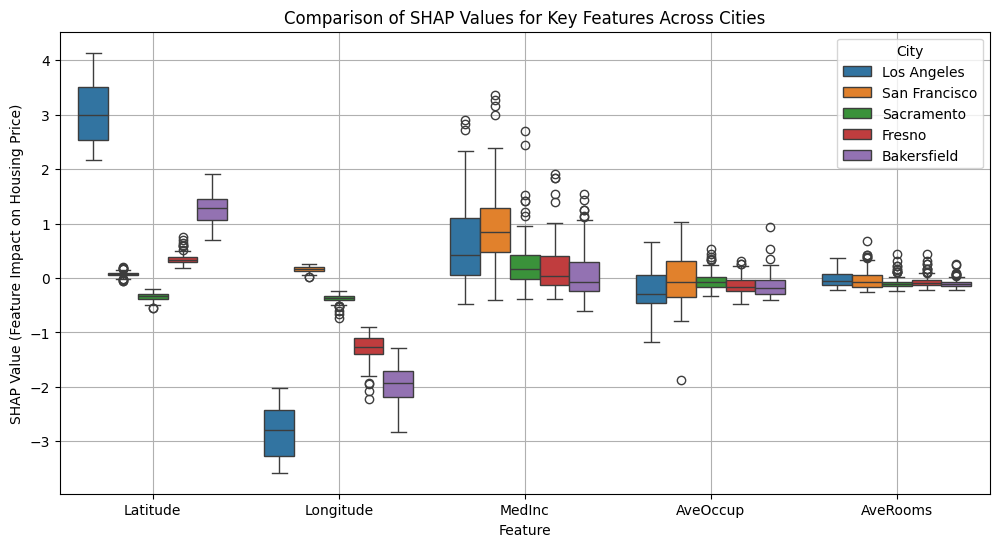

In [29]:
import seaborn as sns

# Select a few important features to compare
features_to_compare = ['Latitude', 'Longitude', 'MedInc', 'AveOccup', 'AveRooms']  
feature_indices = [feature_names.index(f) for f in features_to_compare]

# Prepare data for plotting
data_list = []

for city, (shap_vals, _) in shap_values_city.items():
    for i, feat_idx in enumerate(feature_indices):
        # Extract SHAP values for the feature in this city
        vals = shap_vals[:, feat_idx]
        for val in vals:
            data_list.append({
                'City': city,
                'Feature': features_to_compare[i],
                'SHAP Value': val
            })

df = pd.DataFrame(data_list)

# Plot boxplot
plt.figure(figsize=(12, 6))
sns.boxplot(data=df, x='Feature', y='SHAP Value', hue='City')
plt.title('Comparison of SHAP Values for Key Features Across Cities')
plt.ylabel('SHAP Value (Feature Impact on Housing Price)')

plt.grid(True)
plt.show()

### Read the regional comparison

Compare the mean absolute SHAP values for each selected region. Which feature ranks highest in the displayed subset, and does that ranking match the full-sample plot? Report the sample size and remember that correlated location and income variables can share attribution in model-dependent ways. These plots explain model outputs, not the causes of house prices.


## Step 5: Local explanation

Choose one example and inspect the factors behind its prediction. SHAP breaks down the model output; it does not prove that these features caused real housing-price changes.

While global explanations help understand overall feature importance across the dataset, they may be misleading in cases involving **outliers or atypical samples**. In such cases, **local explanations** can reveal the actual driving forces behind individual prediction and avoid potential bias.

Selected outlier sample index in SF: 15698, house price: 5.00001


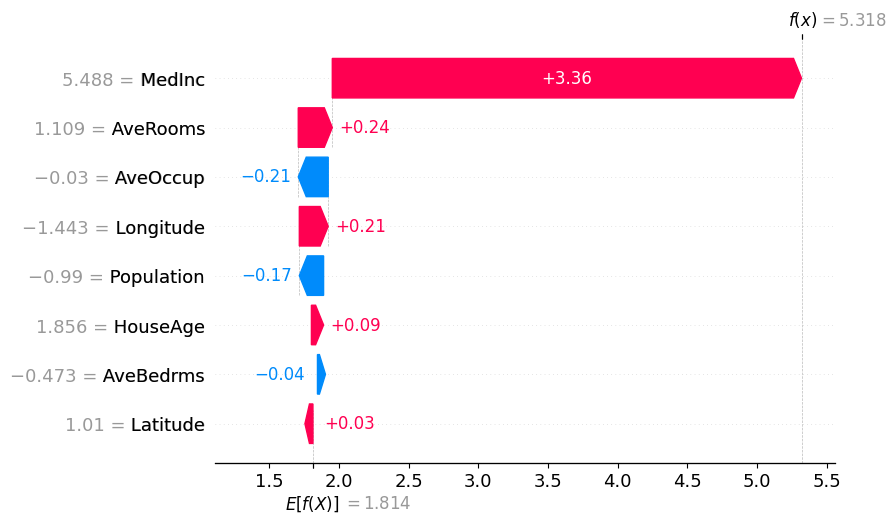

In [31]:
# Step 1: Get indices of all samples within Los Angeles city bounds
sf_indices = city_samples['San Francisco']

# Step 2: Extract true house prices for these SF samples
y_sf = y_california[sf_indices]

# Step 3: Find the sample with the highest house price in SF (outlier)
outlier_idx_sf = np.argmax(y_sf)  # index within la_indices array
outlier_global_idx = sf_indices[outlier_idx_sf]  # index relative to whole dataset

print(f"Selected outlier sample index in SF: {outlier_global_idx}, house price: {y_california[outlier_global_idx]}")

# Step 4: Extract the input features of this outlier sample as a tensor with batch dim
X_outlier = X_tensor[outlier_global_idx].unsqueeze(0)  # shape (1, n_features)

# Step 5: Compute SHAP values for this single outlier sample
shap_values_outlier = explainer.shap_values(X_outlier).squeeze(-1)  # shape (1, n_features) -> (n_features,)

# Step 6: Plot local explanation (waterfall plot) for this outlier sample
expl = shap.Explanation(
    values=shap_values_outlier[0],          
    base_values=explainer.expected_value,  
    data=X_outlier.cpu().numpy()[0],        
    feature_names=feature_names
)

shap.plots.waterfall(expl)

## What to take away

SHAP describes how a model output is attributed to input features. **Try next:** Compare more areas and examples. **Limit:** A model explanation is not a causal conclusion, and correlated features can affect it.